##Citibike Ridership Modeling

*Goal:* build, evaluate, and interpret a Linear Regression model predicting `num_rides` from calendar + weather-forecast features only.

#M1: Split the Data
Load the clean CSV and split into training and test sets with train_test_split (80/20, and set a random_state so your results are reproducible).
 Tip: Keep ride_date out of your feature matrix — it identifies the row, it isn't a feature. Your trend column from C4 carries the time information instead.

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('../data/citibike_weather_preprocessed.csv')

# M1: build X, y
# Excluded: ride_date (identifier, not a feature)
#           avg_duration_min (Rule 1 - not knowable in advance)
#           max_temp_f, min_temp_f (Rule 2 - correlated 0.95-0.98 with temp_f; keeping temp_f only)
exclude_cols = ['ride_date', 'num_rides', 'avg_duration_min', 'max_temp_f', 'min_temp_f']
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]
y = df['num_rides']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Feature columns:", X.columns.tolist())
print("X_train:", X_train.shape, " X_test:", X_test.shape)

Feature columns: ['temp_f', 'wind_speed_knots', 'precip_in', 'month', 'days_since_start', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday']
X_train: (1288, 11)  X_test: (322, 11)


#M2: Fit the Core Model
Fit a LinearRegression on your core feature set: your chosen temperature feature, precipitation, wind, the day-of-week dummies, and your trend feature. Respect both Rules of the Road.



In [7]:
# fit LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print("Model fit complete.")


Model fit complete.


#M3: Evaluate
Report R² on both the training set and the test set. In a markdown cell: what does your test R² mean in plain English, and why do we care about the TEST number more than the training number?
Also, report your test error in real units: MAE and RMSE, in rides. In the same markdown cell, translate MAE into one sentence which ops could actually use (“our prediction is typically off by ___ rides.”) and compare RMSE to MAW. RMSE is always at least as large, and the wider the gap, the more your total error is dominated by a few badly-missed days. Which days do you suspect those are?



In [11]:
# R2, MAE, RMSE
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")
print(f"MAE:  {mae:.1f} rides")
print(f"RMSE: {rmse:.1f} rides")


Train R²: 0.7402
Test R²:  0.7536
MAE:  6715.9 rides
RMSE: 8599.2 rides


On a typical day, the prediction is off by about 6,700 rides, misestimated relative to average daily volume. A handful of days are missed much more badly than that, which the analysis in M5 investigates."

#M4: Interpret the Coefficients
Print your model's coefficients next to their feature names, and translate the three most interesting ones into plain English for the ops team — e.g., “each additional inch of rain costs us roughly ___ rides.” Do the signs match what your EDA led you to expect? Flag any that surprise you.



In [12]:
# coefficients
print("Model Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")
    

Model Coefficients:
temp_f: 537.3962057940909
wind_speed_knots: -351.51236546971296
precip_in: -3836.9966477423677
month: 495.95738874213293
days_since_start: 16.780880394245855
day_of_week_Monday: -982.7539262196349
day_of_week_Saturday: -5772.280405912037
day_of_week_Sunday: -7492.029708190812
day_of_week_Thursday: 986.1068312923833
day_of_week_Tuesday: 492.44773160997266
day_of_week_Wednesday: 1379.2865371794676


#M5: Diagnose With Residuals
Plot residuals (actual − predicted) two ways: against predicted values, and against ride_date. In a markdown cell, describe any patterns — clumps, curves, or drift. A residual plot with structure in it is the model telling you what feature it's missing.
 Tip: If your residuals drift upward or downward over the years, revisit C4 — that's exactly the symptom a trend feature cures.



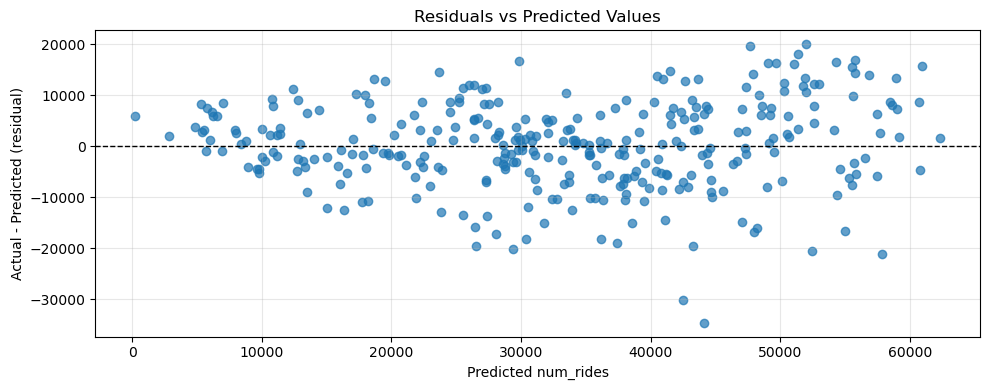

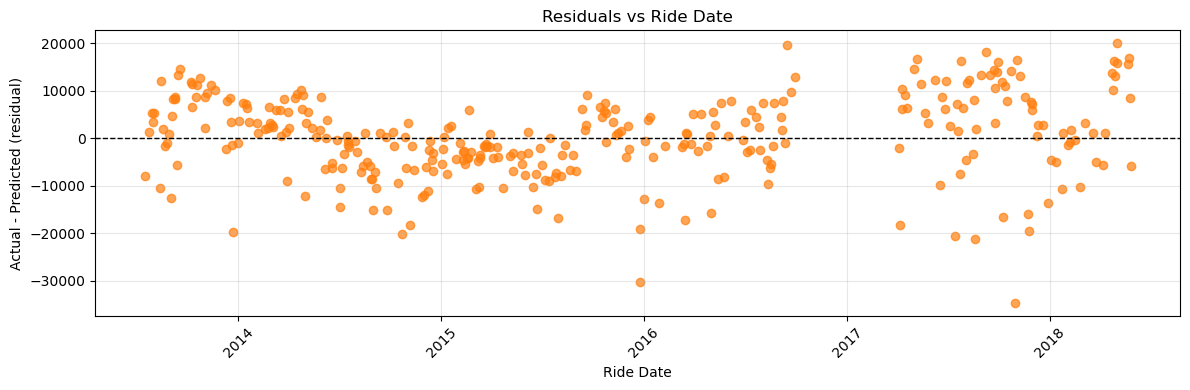

In [13]:
# residual plots
# residual plots
residuals = y_test - y_pred

# Align residuals to their original row dates and plot both residual views
residuals = pd.Series(residuals, index=y_test.index, name='residuals')
test_dates = pd.to_datetime(df.loc[y_test.index, 'ride_date'])

# Residuals vs. predicted rides
plt.figure(figsize=(10, 4))
plt.scatter(y_pred, residuals, alpha=0.7, color='tab:blue')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Predicted num_rides')
plt.ylabel('Actual - Predicted (residual)')
plt.title('Residuals vs Predicted Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Residuals vs. ride date
plt.figure(figsize=(12, 4))
plt.scatter(test_dates, residuals, alpha=0.7, color='tab:orange')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Ride Date')
plt.ylabel('Actual - Predicted (residual)')
plt.title('Residuals vs Ride Date')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#M6: Improve One Thing
Based on your residual diagnosis, make ONE change — add a stretch feature from C5, swap your temperature choice, transform a feature — refit, and compare test R² before vs. after. Keep both results visible in the notebook, even if the change made things worse. Negative results are results.



In [24]:
# refit with one change, compare
exclude_baseline = ['ride_date', 'num_rides', 'avg_duration_min', 'max_temp_f', 'min_temp_f']
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

exclude_new = exclude_baseline + ['month']
X_new = df[[c for c in df.columns if c not in exclude_new]]
xn_train, xn_test, yn_train, yn_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

new_model = LinearRegression().fit(xn_train, yn_train)
new_test_r2 = new_model.score(xn_test, yn_test)
print(exclude_new)
print(f"New Test R²: {new_test_r2:.4f} (previous Test R²: {test_r2:.4f})")
print(f"Change in Test R²: {new_test_r2 - test_r2:.4f}")
print("New model coefficients:")
for feature, coef in zip(X_new.columns, new_model.coef_):
    print(f"{feature}: {coef}") 




['ride_date', 'num_rides', 'avg_duration_min', 'max_temp_f', 'min_temp_f', 'month']
New Test R²: 0.7578 (previous Test R²: 0.7536)
Change in Test R²: 0.0042
New model coefficients:
temp_f: 411.3594367691284
wind_speed_knots: -413.8313364046254
precip_in: -3466.337752635349
days_since_start: 17.28306021330411
day_of_week_Monday: -967.8832757807404
day_of_week_Saturday: -5807.22427197541
day_of_week_Sunday: -7425.549586260397
day_of_week_Thursday: 1059.8124269964926
day_of_week_Tuesday: 664.3549080354065
day_of_week_Wednesday: 1546.339565435102
month_sin: -4498.13908115542
month_cos: -1823.3499332952401
